# Análisis de Flujo: $\dot{x} = \sin(x)$

Objetivo: entender por qué la solución **no** es $\cos(x)$, y cómo el análisis de flujo (graphing $f(x)=\sin(x)$) permite sacar conclusiones sobre puntos fijos, estabilidad y comportamiento a largo plazo.

## 1. ¿Por qué la solución no es $\cos(x)$?

La ecuación es separable:

$$\frac{dx}{dt} = \sin(x) \quad \Rightarrow \quad \int \frac{dx}{\sin(x)} = \int dt$$

El error viene de confundir **integrar** $\sin(x)$ con **resolver** la ecuación. Acá el seno está en el **denominador** de una integral:

$$\int \csc(x)\,dx = \ln\left|\csc(x) - \cot(x)\right| + C \neq \cos(x)$$

Recordemos que $\int \sin(x)\,dx = -\cos(x) + C$ es otra cosa completamente distinta.

Además, en esta ecuación **$x$ es la función** $x(t)$, no una variable. La pregunta real es: ¿qué función, al derivarla, da el seno de sí misma?

## 2. Análisis de flujo: gráfico de $f(x) = \sin(x)$

La clave: el **signo** de $f(x) = \sin(x)$ en cada punto te dice cómo se mueve $x$:

- $\sin(x) > 0 \Rightarrow \dot{x} > 0 \Rightarrow x$ **aumenta** (flecha $\to$)
- $\sin(x) < 0 \Rightarrow \dot{x} < 0 \Rightarrow x$ **disminuye** (flecha $\leftarrow$)
- $\sin(x) = 0 \Rightarrow$ **punto fijo**

Los puntos fijos son donde $\sin(x) = 0$: $x = 0, \pi, 2\pi, \ldots$

<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/nix-shell-594072-416539262/ipykernel_594912/2618033504.py:14: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.annotate(f'$x={x0/np.pi:.0f}\pi$', (x0, -0.15), ha='center', color='red', fontsize=9)


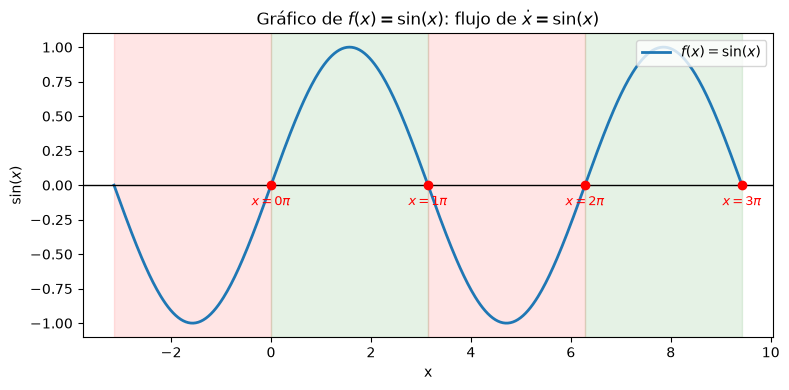

Regiones verde: sin(x)>0 -> x aumenta (flecha a la derecha)
Regiones roja : sin(x)<0 -> x disminuye (flecha a la izquierda)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_vals = np.linspace(-np.pi, 3*np.pi, 500)
fvals = np.sin(x_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, fvals, label=r'$f(x)=\sin(x)$', lw=2)
ax.axhline(0, color='k', lw=1)

# Mark fixed points (sin = 0)
for x0 in [0, np.pi, 2*np.pi, 3*np.pi]:
    ax.scatter([x0], [0], color='red', zorder=5)
    ax.annotate(f'$x={x0/np.pi:.0f}\pi$', (x0, -0.15), ha='center', color='red', fontsize=9)

# Zero line
ax.set_xlabel('x')
ax.set_ylabel(r'$\sin(x)$')
ax.set_title('Gráfico de $f(x)=\\sin(x)$: flujo de $\\dot{x}=\\sin(x)$')
ax.axvspan(-np.pi, 0, color='red', alpha=0.1)
ax.axvspan(0, np.pi, color='green', alpha=0.1)
ax.axvspan(np.pi, 2*np.pi, color='red', alpha=0.1)
ax.axvspan(2*np.pi, 3*np.pi, color='green', alpha=0.1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Regiones verde: sin(x)>0 -> x aumenta (flecha a la derecha)")
print("Regiones roja : sin(x)<0 -> x disminuye (flecha a la izquierda)")

## 3. Estabilidad de los puntos fijos

Se lee mirando las flechas **alrededor** de cada punto fijo:

- **$x = 0$**: a la izquierda $\sin(x)<0$ (flecha $\leftarrow$), a la derecha $\sin(x)>0$ (flecha $\to$). Las flechas **se alejan** $\Rightarrow$ **inestable**.
- **$x = \pi$**: a la izquierda $\sin(x)>0$ (flecha $\to$), a la derecha $\sin(x)<0$ (flecha $\leftarrow$). Las flechas **convergen** $\Rightarrow$ **estable**.

<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/nix-shell-594072-416539262/ipykernel_594912/3214666025.py:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.annotate(f'${x0/np.pi:.0f}\pi$', (x0, 0.25), ha='center', fontsize=10)


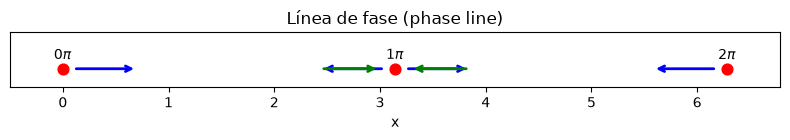

In [2]:
fig, ax = plt.subplots(figsize=(8, 1.5))
x0s = [0, np.pi, 2*np.pi]

for x0 in x0s:
    ax.scatter([x0], [0], color='red', s=60, zorder=5)
    ax.annotate(f'${x0/np.pi:.0f}\pi$', (x0, 0.25), ha='center', fontsize=10)
    # arrows away from 0 (inestable): <-- and -->
    ax.annotate('', xy=(x0-0.7, 0), xytext=(x0-0.1, 0), arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.annotate('', xy=(x0+0.7, 0), xytext=(x0+0.1, 0), arrowprops=dict(arrowstyle='->', lw=2, color='blue'))

for x0 in [np.pi]:
    # arrows toward pi (estable): -> and <-
    ax.annotate('', xy=(x0-0.15, 0), xytext=(x0-0.7, 0), arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    ax.annotate('', xy=(x0+0.15, 0), xytext=(x0+0.7, 0), arrowprops=dict(arrowstyle='->', lw=2, color='green'))

ax.set_xlim(-0.5, 2*np.pi+0.5)
ax.set_ylim(-0.5, 1)
ax.set_yticks([])
ax.set_xlabel('x')
ax.set_title('Línea de fase (phase line)')
plt.tight_layout()
plt.show()

## 4. Solución explícita para $x_0 = \pi/4$

De la forma implícita $\ln|\csc(x)-\cot(x)| = t + C$ y usando la identidad $\csc(x)-\cot(x)=\tan(x/2)$:

$$\tan\left(\frac{x}{2}\right) = (\sqrt{2}-1)\,e^{t}$$

$$x(t) = 2\,\arctan\left((\sqrt{2}-1)\,e^{t}\right)$$

Verificación de límites:
- $t=0$: $2\arctan(\sqrt{2}-1) = \pi/4$ ✅
- $t\to\infty$: $\arctan \to \pi/2$, así que $x \to 2(\pi/2) = \pi$ ✅

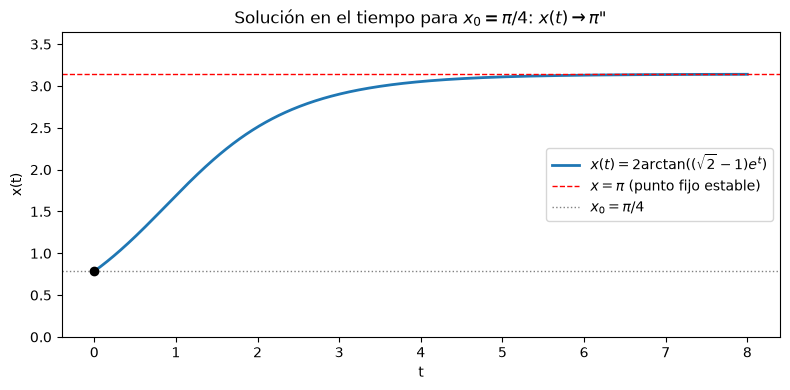

x(0)      = 0.785398 (esperado pi/4 = 0.785398)
x(inf)    -> 3.141593 (esperado pi = 3.141593)


In [3]:
x0 = np.pi / 4
ts = np.linspace(0, 8, 500)
xt = 2 * np.arctan((np.sqrt(2) - 1) * np.exp(ts))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, xt, lw=2, label=r'$x(t)=2\arctan((\sqrt{2}-1)e^t)$')
ax.axhline(np.pi, color='red', ls='--', lw=1, label=r'$x=\pi$ (punto fijo estable)')
ax.axhline(x0, color='gray', ls=':', lw=1, label=r'$x_0=\pi/4$')
ax.scatter([0], [x0], color='black', zorder=5)
ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_title('Solución en el tiempo para $x_0=\\pi/4$: $x(t)\\to\\pi$"')
ax.set_ylim(0, np.pi + 0.5)
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f'x(0)      = {xt[0]:.6f} (esperado pi/4 = {np.pi/4:.6f})')
print(f'x(inf)    -> {2*np.arctan(1e10):.6f} (esperado pi = {np.pi:.6f})')

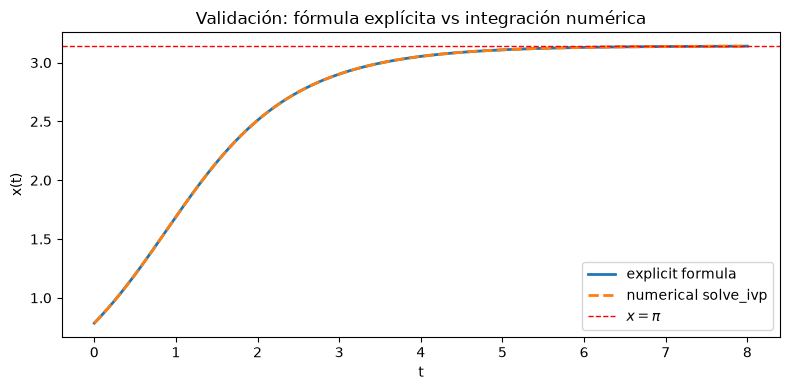

Max difference = 1.88e-09  (la fórmula explícita es correcta)


In [4]:
import scipy.integrate as si

# Numerically integrate to confirm the explicit solution matches the ODE
def rhs(t, y):
    return np.sin(y)

num = si.solve_ivp(rhs, [0, 8], [np.pi/4], t_eval=ts, rtol=1e-10, atol=1e-12)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, xt, lw=2, label='explicit formula')
ax.plot(num.t, num.y[0], '--', lw=2, label='numerical solve_ivp')
ax.axhline(np.pi, color='red', ls='--', lw=1, label=r'$x=\pi$')
ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_title('Validación: fórmula explícita vs integración numérica')
ax.legend()
plt.tight_layout()
plt.show()

err = np.max(np.abs(xt - num.y[0]))
print(f'Max difference = {err:.2e}  (la fórmula explícita es correcta)' if err < 1e-5 else 'ERROR: no coincide')

## 5. Animación: diagrama de flujo vs. solución real

Esta animación relaciona las dos vistas que ya vimos. A la izquierda está el **diagrama de flujo** (el gráfico de $f(x)=\sin(x)$ y dónde está el punto $x(t)$ sobre el eje), y a la derecha la **solución real** $x(t)=2\arctan((\sqrt{2}-1)e^t)$ contra el tiempo. A medida que $t$ crece, el punto se mueve hacia la derecha en el flujo (donde $\sin(x)>0$) y la curva converge a su asíntota $x=\pi$ cuando $t\to\infty$.

In [5]:
%load_ext manim.utils.ipython_magic

The manim.utils.ipython_magic module is not an IPython extension.


Manim Community v0.20.1

[08/31/26 23:58:07] INFO     Animation 0 : Using cached data (hash :                           ]8;id=7648890;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=7648891;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/renderer/cairo_renderer.py#94\94]8;;\
                             1987512680_2027047829_1108090363)                                                     


Animation 0: Create(Axes of 2 submobjects), etc.:   0%|          | 0/1 [00:00<?, ?it/s]


Animation 1: Create(Axes of 2 submobjects), etc.:   0%|          | 0/30 [00:00<?, ?it/s]


Animation 1: Create(Axes of 2 submobjects), etc.:  40%|████      | 12/30 [00:00<00:00, 112.49it/s]

...

[08/31/26 23:58:10] INFO     Animation 3 : Using cached data (hash :                           ]8;id=7648910;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/renderer/cairo_renderer.py\cairo_renderer.py]8;;\:]8;id=7648911;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/renderer/cairo_renderer.py#94\94]8;;\
                             2538612922_4028536258_2645117637)                                                     


Waiting 3:   0%|          | 0/1 [00:00<?, ?it/s]

                    INFO     Combining to Movie file.                                      ]8;id=7648917;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=7648918;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

[08/31/26 23:58:15] INFO                                                                   ]8;id=7648924;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=7648925;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/matias/Database/files/Repos/UBA/ModeladoContinuo/teori                         
                             cas/media/videos/teoricas/720p30/FlujoVsSolucion_ManimCE_v0.2                         
                             0.1.gif'                                                                              
                                                                                                                   

                    INFO     Rendered FlujoVsSolucion                                                  ]8;id=7648932;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=7648933;file:///nix/store/1bps7z1lzb7770abdm3g2yfl8qiqqz2n-python3-3.14.6-env/lib/python3.14/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 4 animations                                                                   

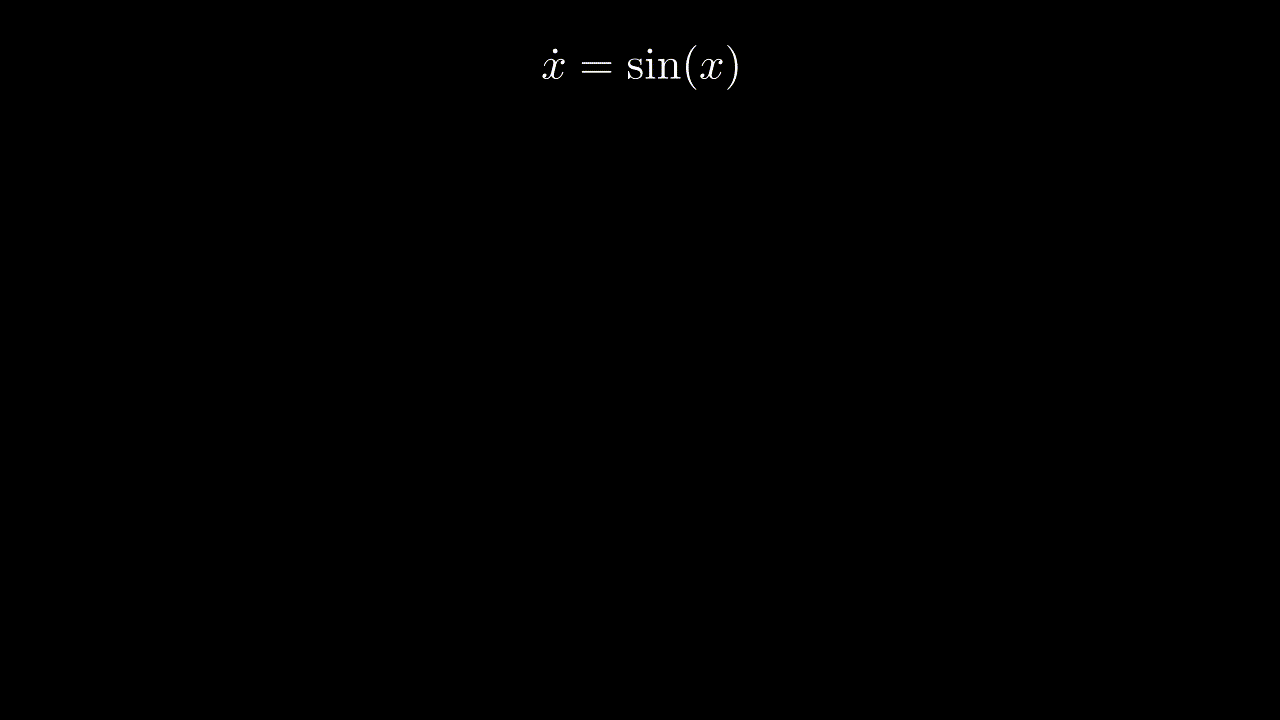

In [6]:
%%manim -qm --format gif FlujoVsSolucion
from manim import *
import numpy as np

class FlujoVsSolucion(Scene):
    def construct(self):
        axes_flow = Axes(
            x_range=[0, 2*np.pi + 0.5, 1],
            y_range=[-1.2, 1.2, 0.5],
            x_length=5.0,
            y_length=2.6,
            axis_config={"include_tip": True},
        ).to_edge(LEFT)
        flow_label = MathTex(r"f(x)=\sin(x)").scale(0.7).next_to(axes_flow, UP, buff=0.1)
        graph = axes_flow.plot(lambda x: np.sin(x), color=BLUE)
        pi_line = DashedLine(axes_flow.c2p(np.pi, -1.2), axes_flow.c2p(np.pi, 1.2),
                             color=RED, stroke_width=2, dash_length=0.05)
        pi_label = MathTex(r"x=\pi").scale(0.6).set_color(RED).next_to(pi_line, UP, buff=0.05)
        dot_flow = Dot(color=YELLOW, radius=0.08).move_to(axes_flow.c2p(np.pi/4, 0))

        axes_sol = Axes(
            x_range=[0, 6, 1],
            y_range=[0, np.pi + 0.3, 1],
            x_length=5.0,
            y_length=2.6,
            axis_config={"include_tip": True},
        ).to_edge(RIGHT)
        sol_label = MathTex(r"x(t)").scale(0.7).next_to(axes_sol, UP, buff=0.1)
        sol_graph = axes_sol.plot(lambda t: 2*np.arctan((np.sqrt(2)-1)*np.exp(t)), color=GREEN)
        asymptote = DashedLine(axes_sol.c2p(0, np.pi), axes_sol.c2p(6, np.pi),
                               color=RED, stroke_width=2, dash_length=0.05)
        asym_label = MathTex(r"x=\pi").scale(0.6).set_color(RED).next_to(asymptote, RIGHT, buff=0.05)
        dot_sol = Dot(color=YELLOW, radius=0.08).move_to(axes_sol.c2p(0, np.pi/4))
        trail = TracedPath(dot_sol.get_center, stroke_color=GREEN_A, stroke_width=3)

        title = MathTex(r"\dot{x} = \sin(x)").to_edge(UP)
        self.add(title)
        self.play(Create(axes_flow), Create(graph), Write(flow_label), Create(pi_line), Write(pi_label))
        self.play(Create(axes_sol), Create(sol_graph), Write(sol_label), Create(asymptote), Write(asym_label))
        self.add(trail, dot_flow, dot_sol)

        def update_flow(mob):
            t = mob.get_value()
            xval = 2*np.arctan((np.sqrt(2)-1)*np.exp(t))
            dot_flow.move_to(axes_flow.c2p(xval, 0))
            dot_sol.move_to(axes_sol.c2p(t, xval))
            return mob

        tracker = ValueTracker(0.0)
        tracker.add_updater(update_flow)
        self.add(tracker)
        self.play(tracker.animate.set_value(6.0), run_time=6, rate_func=linear)
        self.wait(1)

## Resumen

1. $\dot{x}=\sin(x)$ es separable: la integral que aparece es $\int\csc(x)\,dx$, que da $\ln|\csc(x)-\cot(x)|$, no $\cos(x)$.
2. $x$ es una **función** $x(t)$, no una variable.
3. El **signo** de $f(x)=\sin(x)$ da la dirección del flujo en cada punto.
4. Puntos fijos donde $\sin(x)=0$; estables cuando las flechas convergen, inestables cuando divergen.
5. Para $x_0=\pi/4$, la solución $x(t)=2\arctan((\sqrt{2}-1)e^t)$ crece y tiende a $x=\pi$ cuando $t\to\infty$.